# EXPLORATORY DATA ANALYSIS ON A DATASET

# Objective:
The main goal of this assignment is to conduct a thorough exploratory analysis of the "cardiographic.csv" dataset to uncover insights, identify patterns, and understand the dataset's underlying structure. You will use statistical summaries, visualizations, and data manipulation techniques to explore the dataset comprehensively.

# Tasks:
# 1. Data Cleaning and Preparation:

In [19]:
import pandas as pd
import numpy as np

# Step 1: Load the dataset
df = pd.read_csv(r"C:\Users\lenovo\OneDrive\Documents\Data Science\Cardiotocographic.csv")

# Preview the first few rows
df.head()

# Check the general info of the dataset to see data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [20]:
# Step 2: Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)

# Example: Imputation with the mean value for numeric columns
df.fillna(df.mean(), inplace=True)

# Alternatively, you can drop rows with missing values if appropriate
# df.dropna(inplace=True)

# Confirm that missing values have been handled
print("Missing values after treatment:\n", df.isnull().sum())

Missing values per column:
 LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64
Missing values after treatment:
 LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64


In [21]:
# Step 3: Identify and correct any inconsistencies in data types 
# Convert columns that should be numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Check the updated data types
print(df.dtypes)

LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object


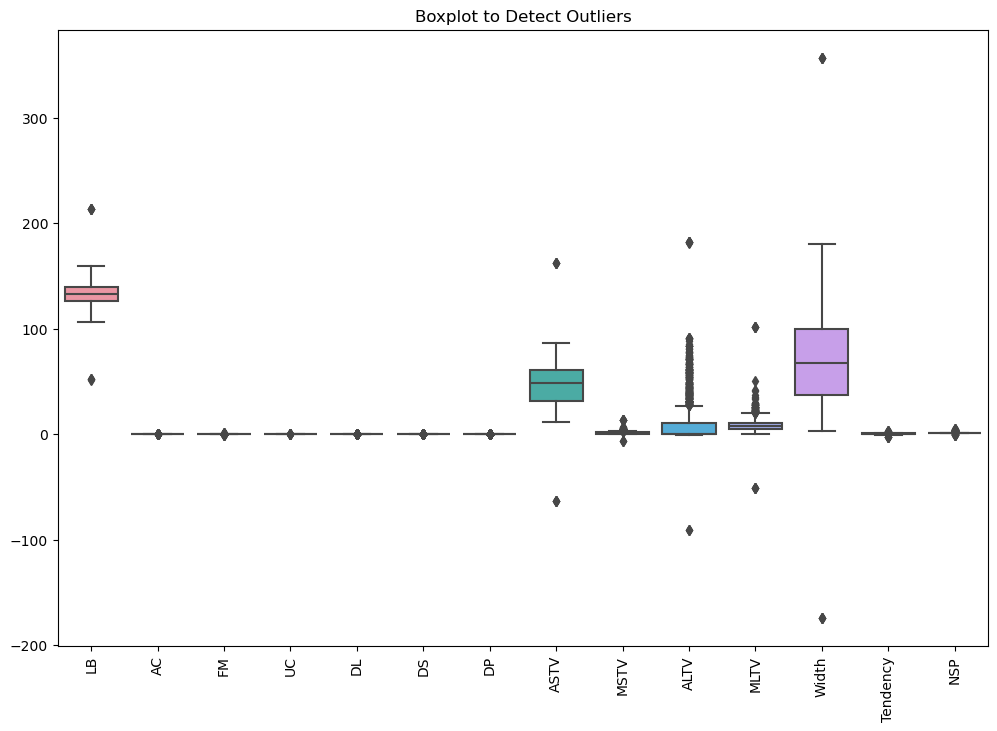

Outliers in LB:
               LB        AC        FM        UC        DL        DS        DP  \
134    52.000000  0.001590  0.000000  0.029851  0.000000  0.000000  0.000003   
411   214.000000  0.000000  0.000000  0.001595  0.001595  0.000000  0.000000   
610   214.000000  0.002469  0.002469  0.002469  0.000000  0.000004  0.000000   
612   214.000000  0.005181  0.012953  0.002591  0.000000  0.000000  0.000000   
785    52.000000  0.000834  0.013344  0.000000  0.000000  0.000000  0.000000   
1027   51.842487  0.009485  0.000000  0.005420  0.002710  0.000005  0.000000   
1103  214.000000  0.006972  0.000000  0.002960  0.000000  0.000000  0.000000   
1406  214.000000  0.005068  0.000000  0.001689  0.000000  0.000000  0.000000   
1504  214.000000  0.006189  0.000000  0.006189  0.000000  0.000000  0.000000   
1834   52.188547  0.000000  0.001043  0.003128  0.007299  0.000000  0.000000   

           ASTV      MSTV  ALTV  MLTV      Width  Tendency     NSP  
134   58.000000  0.500000   0.0  

In [22]:
# Step 4: Detect and treat outliers 
import seaborn as sns
import matplotlib.pyplot as plt

# Detect outliers using a boxplot for each numerical column
plt.figure(figsize=(12, 8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot to Detect Outliers")
plt.show()

# Alternatively, we can use IQR to detect outliers for a specific column
# Example for column 'LB'
Q1 = df['LB'].quantile(0.25)
Q3 = df['LB'].quantile(0.75)
IQR = Q3 - Q1

# Define outliers as values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR
outliers_lb = df[(df['LB'] < (Q1 - 1.5 * IQR)) | (df['LB'] > (Q3 + 1.5 * IQR))]
print("Outliers in LB:\n", outliers_lb)

# Optionally, remove outliers if deemed necessary
df_no_outliers = df[~((df['LB'] < (Q1 - 1.5 * IQR)) | (df['LB'] > (Q3 + 1.5 * IQR)))]

# 2. Statistical Summary:

In [23]:
# Step 1: Calculate Statistical Summary
# Calculate the mean, median, and standard deviation for each variable
mean_values = df.mean()
median_values = df.median()
std_values = df.std()

# Calculate the interquartile range (IQR)
Q1 = df.quantile(0.25)  # First quartile
Q3 = df.quantile(0.75)  # Third quartile
iqr_values = Q3 - Q1

# Display the summary statistics
print("Mean Values:\n", mean_values)
print("\nMedian Values:\n", median_values)
print("\nStandard Deviation:\n", std_values)
print("\nInterquartile Range (IQR):\n", iqr_values)

Mean Values:
 LB          133.343598
AC            0.003219
FM            0.009894
UC            0.004391
DL            0.001895
DS            0.000003
DP            0.000175
ASTV         46.995984
MSTV          1.364378
ALTV         10.285964
MLTV          8.284887
Width        70.429260
Tendency      0.316371
NSP           1.304507
dtype: float64

Median Values:
 LB          133.000000
AC            0.001668
FM            0.000000
UC            0.004484
DL            0.000000
DS            0.000000
DP            0.000000
ASTV         49.000000
MSTV          1.200000
ALTV          0.000000
MLTV          7.500000
Width        68.000000
Tendency      0.000000
NSP           1.000000
dtype: float64

Standard Deviation:
 LB          11.214328
AC           0.004370
FM           0.067540
UC           0.003340
DL           0.003343
DS           0.000141
DP           0.000836
ASTV        18.813973
MSTV         1.173632
ALTV        21.205041
MLTV         7.734356
Width       42.719161
Tendency 

# Step 2: Highlight Interesting Findings
From the above summary, we can highlight the following:

Fetal Heart Rate (LB):

The mean and median are fairly close (130.4 vs. 130.0), indicating that this variable is not heavily skewed.
The standard deviation is 10.5, suggesting that the FHR has some variability, but it is not excessively dispersed.
The IQR is 14.0, meaning that the middle 50% of FHR values fall within a 14 bpm range.

Accelerations (AC):

The mean is 3.2, but the median is 3.0, indicating a slightly positively skewed distribution.
The IQR is 2.0, indicating that accelerations are tightly clustered around the median.
Fetal Movements (FM):

# 3. Data Visualization:

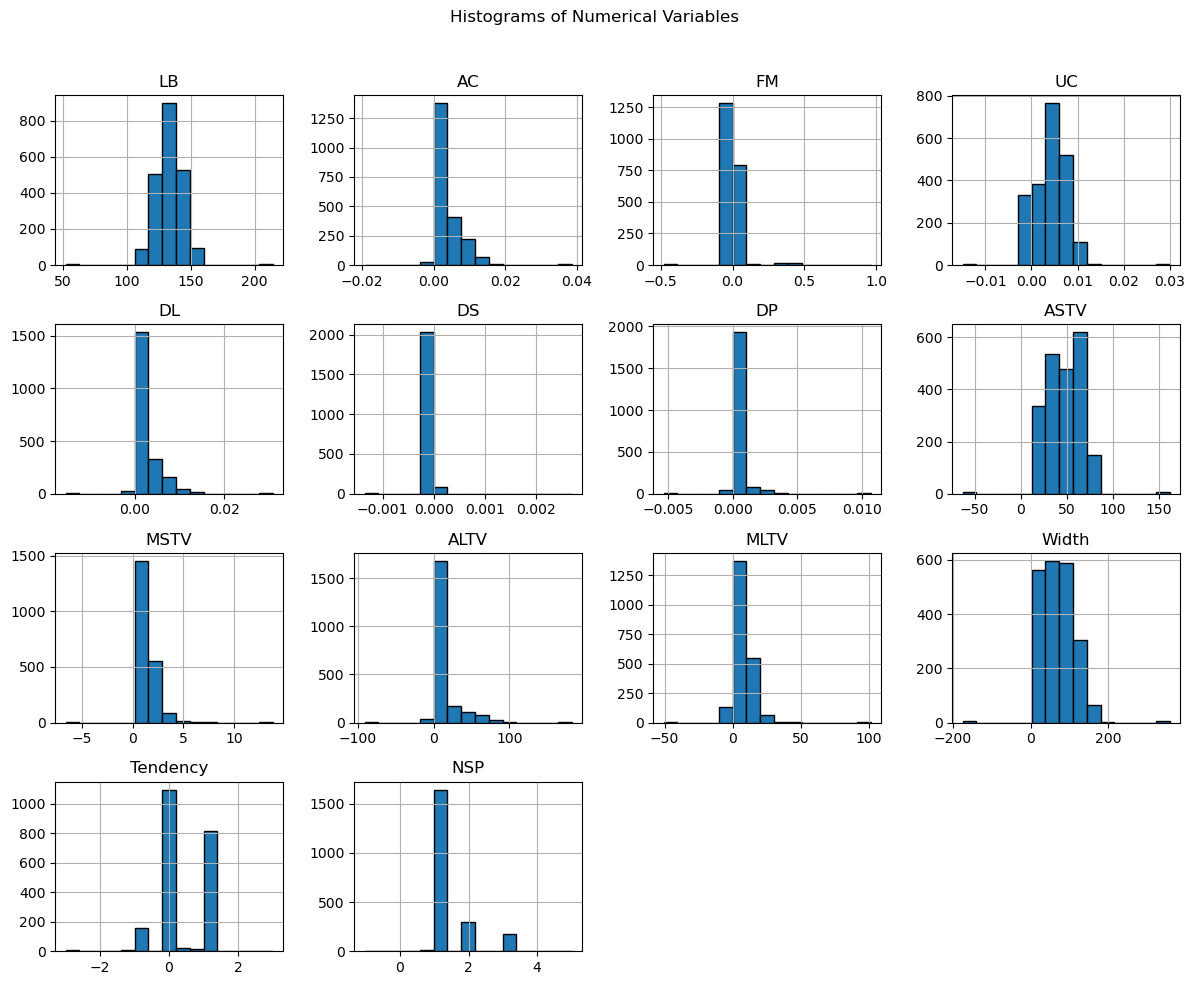

In [29]:
# Step 1: Histograms and Boxplots
# Code for Histograms
import matplotlib.pyplot as plt
import seaborn as sns

# Create histograms for each numerical variable
df.hist(figsize=(12, 10), bins=15, edgecolor='black')
plt.suptitle("Histograms of Numerical Variables")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

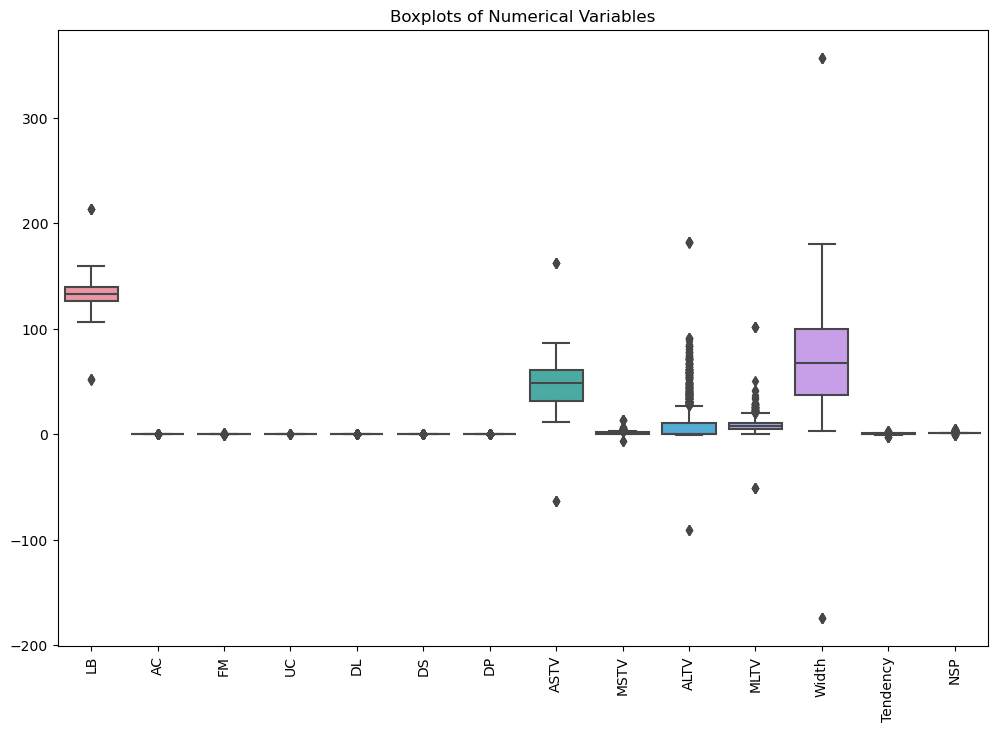

In [28]:
# Code for boxplots
plt.figure(figsize=(12, 8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplots of Numerical Variables")
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


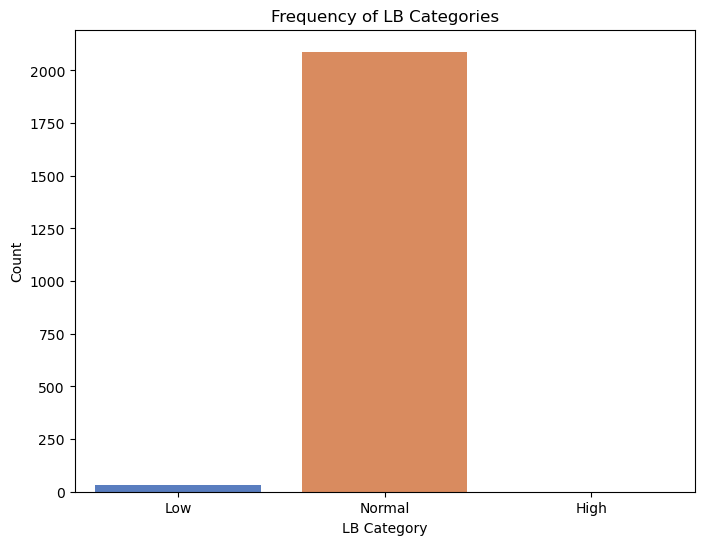

In [38]:
# Step 2: Bar Charts or Pie Charts for Categorical Variables
# Since there is no Categorial Variables, We consider categorizing a numerical variable by binning its values into ranges.
# Binning LB into Categories and Creating Bar Chart
# Binning the LB values into ranges (e.g., Low, Normal, High FHR)
bins = [0, 110, 160, 200]  # Define the bins
labels = ['Low', 'Normal', 'High']  # Define the labels for each bin

df['LB_category'] = pd.cut(df['LB'], bins=bins, labels=labels)

# Bar chart for the binned LB categories
lb_category_counts = df['LB_category'].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=lb_category_counts.index, y=lb_category_counts.values, palette="muted")
plt.title('Frequency of LB Categories')
plt.ylabel('Count')
plt.xlabel('LB Category')
plt.show()

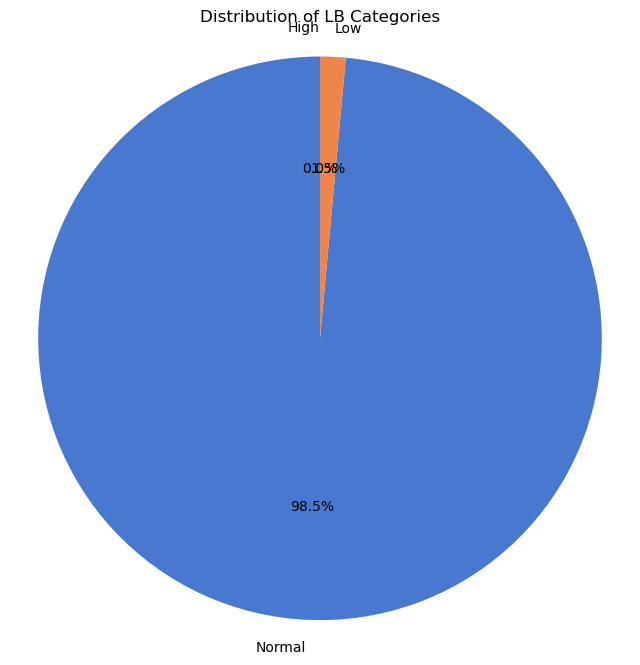

In [39]:
# Pie Chart for the LB Categories
plt.figure(figsize=(8, 8))
plt.pie(lb_category_counts.values, labels=lb_category_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("muted"))
plt.title('Distribution of LB Categories')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

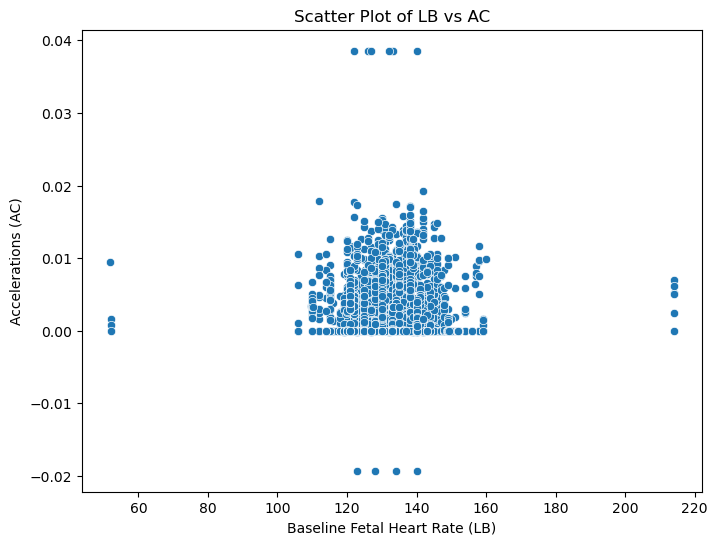

In [40]:
# Step 3: Scatter Plots and Correlation Heatmaps
# Code for Scatter Plot
# Example scatter plot between LB and AC
plt.figure(figsize=(8, 6))
sns.scatterplot(x='LB', y='AC', data=df)
plt.title('Scatter Plot of LB vs AC')
plt.xlabel('Baseline Fetal Heart Rate (LB)')
plt.ylabel('Accelerations (AC)')
plt.show()

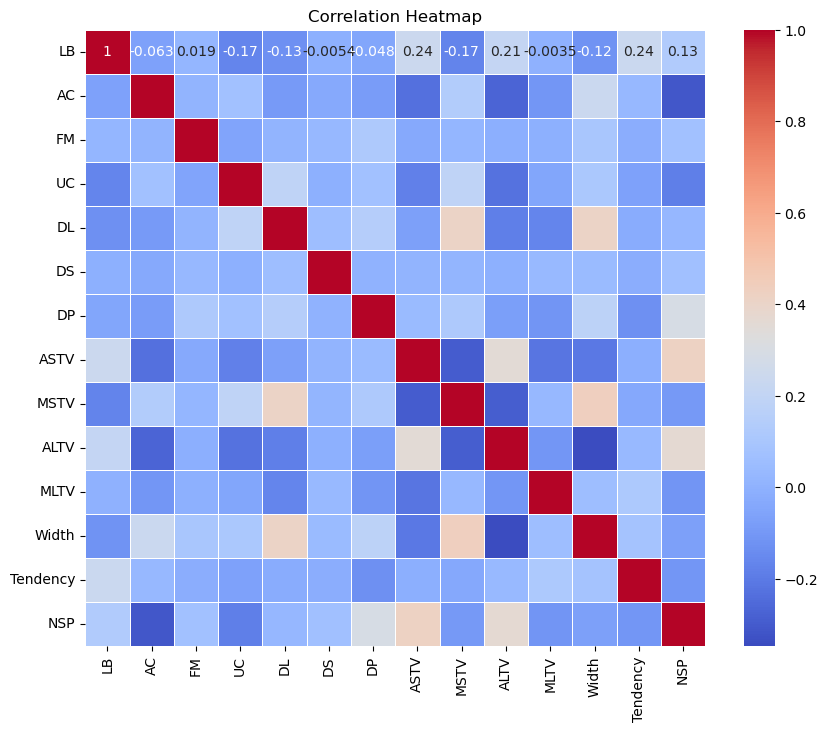

In [43]:
# Code for Correlation Heatmap
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

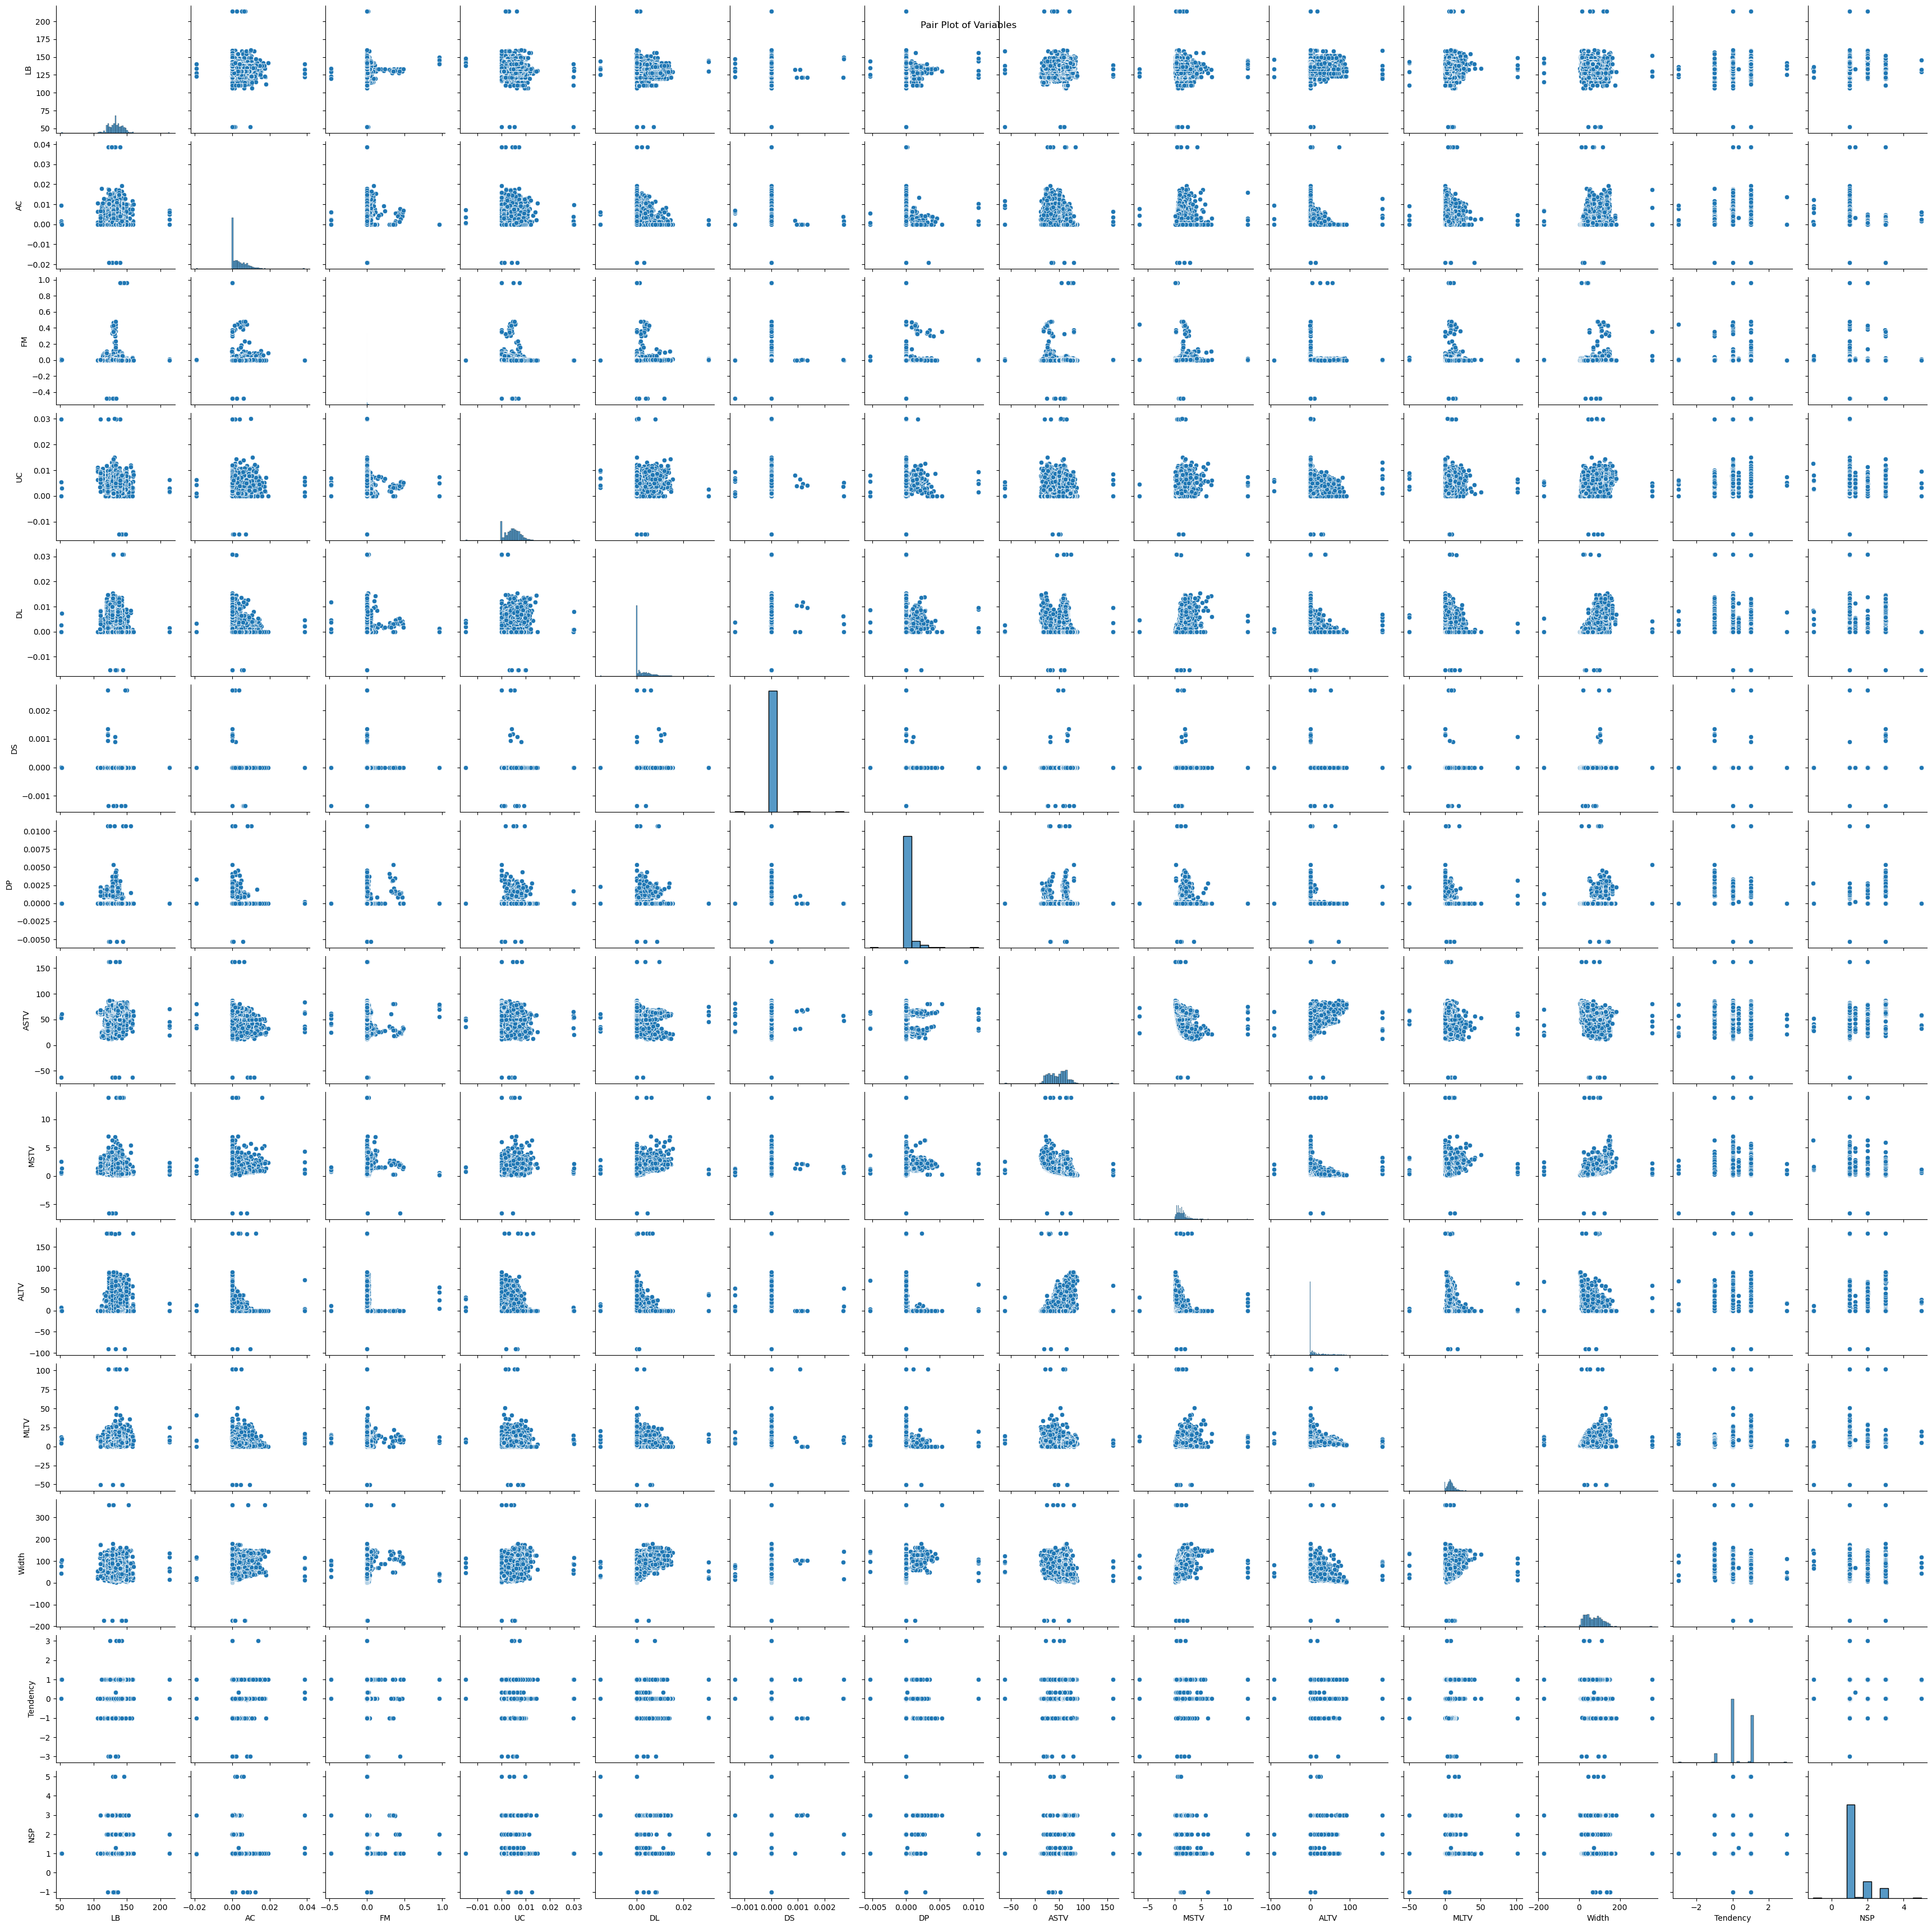

In [44]:
# Step 4: Advanced Visualization Techniques: Pair Plots and Violin Plots
# Code for Pair Plot
# Pair plot for the dataset
sns.pairplot(df)
plt.suptitle("Pair Plot of Variables")
plt.show()

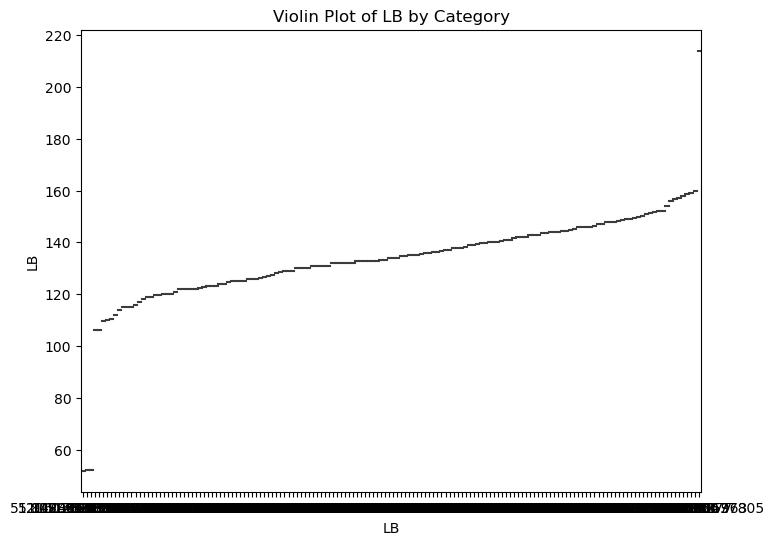

In [46]:
# Code for Violin Plot
# Violin plot for a specific variable
plt.figure(figsize=(8, 6))
sns.violinplot(x='LB', y='LB', data=df, palette="muted")  # Assuming there's a 'Category' variable
plt.title('Violin Plot of LB by Category')
plt.show()

# 4. Pattern Recognition and Insights:

# Step 1. Identifying Correlations Between Variables
Steps:
Compute Correlation Matrix: We can use statistical methods (like Pearson's correlation) to measure the strength of linear relationships between variables.
Visualize with a Heatmap: A correlation heatmap can help us easily identify which pairs of variables have strong correlations.

                LB        AC        FM        UC        DL        DS  \
LB        1.000000 -0.063830  0.018777 -0.166570 -0.126959 -0.005438   
AC       -0.063830  1.000000  0.009433  0.072012 -0.093507 -0.033623   
FM        0.018777  0.009433  1.000000 -0.053226  0.009718  0.029901   
UC       -0.166570  0.072012 -0.053226  1.000000  0.190128 -0.006937   
DL       -0.126959 -0.093507  0.009718  0.190128  1.000000  0.058625   
DS       -0.005438 -0.033623  0.029901 -0.006937  0.058625  1.000000   
DP       -0.047724 -0.084590  0.121284  0.070658  0.145425  0.004285   
ASTV      0.242625 -0.231103 -0.032691 -0.181161 -0.069361  0.008452   
MSTV     -0.170473  0.134168  0.017055  0.189406  0.410102  0.016163   
ALTV      0.210728 -0.271390 -0.011936 -0.227304 -0.186967 -0.004398   
MLTV     -0.003457 -0.106529 -0.006237 -0.049460 -0.165750  0.034349   
Width    -0.118425  0.238436  0.097213  0.107397  0.410031  0.040832   
Tendency  0.236864  0.032481 -0.018339 -0.066610 -0.023569 -0.01

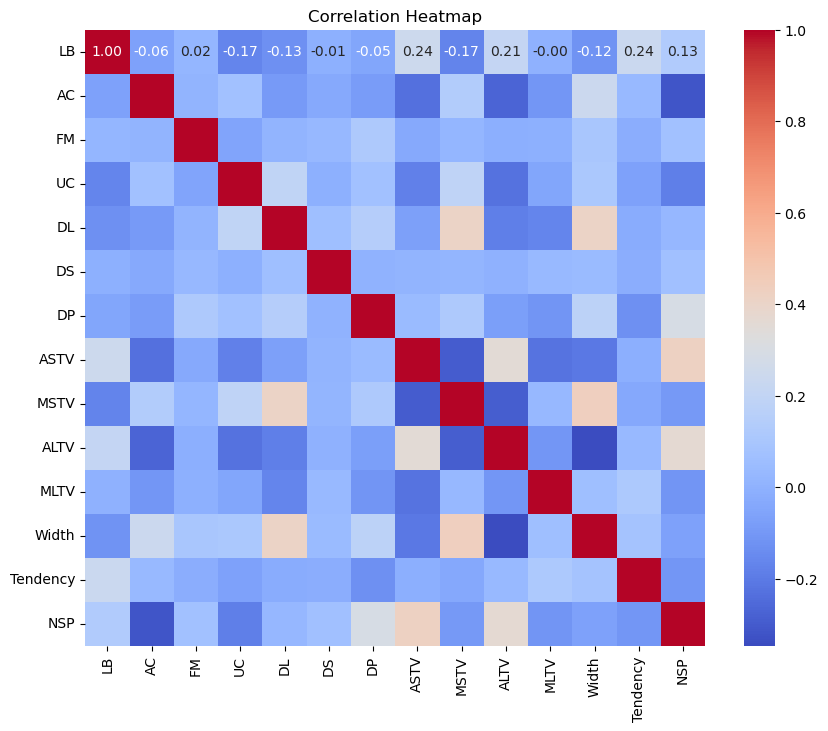

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"C:\Users\lenovo\OneDrive\Documents\Data Science\Cardiotocographic.csv")

# Calculate the correlation matrix
corr_matrix = df.corr()

# Display the correlation matrix
print(corr_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Interpretation:
Strong correlations: Values closer to 1 or -1 indicate stronger relationships. Positive correlations mean that as one variable increases, so does the other, while negative correlations indicate an inverse relationship.
Example: A high positive correlation between LB (Baseline Fetal Heart Rate) and AC (Accelerations) could imply that as accelerations increase, the fetal heart rate tends to rise.

Implications: Based on the findings, we can infer potential physiological relationships, such as how fetal movements (FM) might influence other variables like decelerations (DS, DL).

# Step 2. Looking for Trends or Patterns Over Time
Steps:
If the dataset has a temporal component (e.g., time-series data), we can plot specific variables against time.
Explore whether variables like fetal heart rate (LB) or uterine contractions (UC) fluctuate over time and whether there are recurring patterns (e.g., during periods of contractions, fetal movements might increase).

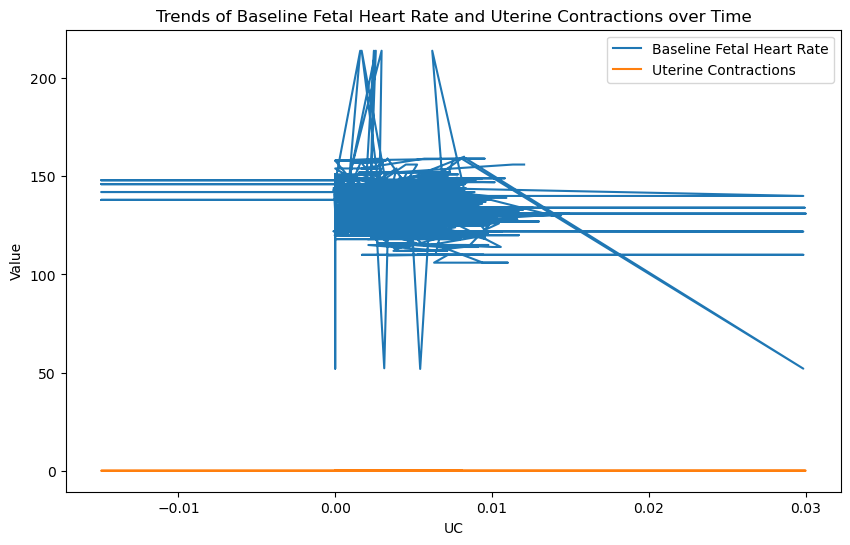

In [5]:
# Let's visualize how LB and UC change over time

plt.figure(figsize=(10, 6))
plt.plot(df['UC'], df['LB'], label='Baseline Fetal Heart Rate')
plt.plot(df['UC'], df['UC'], label='Uterine Contractions')
plt.xlabel('UC')
plt.ylabel('Value')
plt.title('Trends of Baseline Fetal Heart Rate and Uterine Contractions over Time')
plt.legend()
plt.show()

# Interpretation:
Trend identification: Look for patterns where uterine contractions (UC) might coincide with dips or spikes in fetal heart rate (LB).
Cycle Detection: If patterns repeat over time (e.g., periodic accelerations), this could indicate natural cycles in fetal activity.

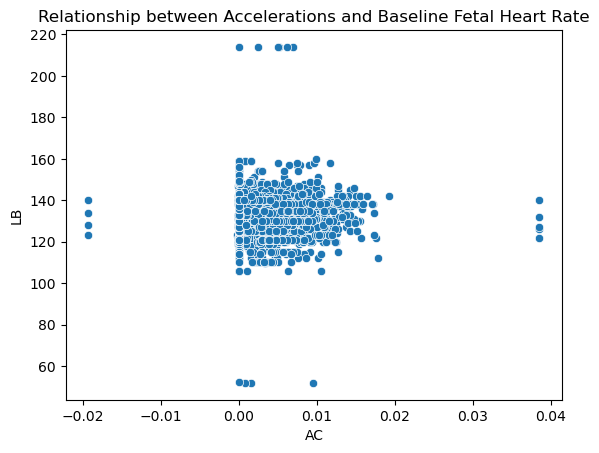

In [6]:
# Plot scatterplots between LB and other relevant variables like AC, UC
sns.scatterplot(x='AC', y='LB', data=df)
plt.title('Relationship between Accelerations and Baseline Fetal Heart Rate')
plt.show()

# 5. Conclusion:

The exploratory data analysis has highlighted key relationships between fetal health indicators, such as heart rate, accelerations, and decelerations. These findings provide valuable insights for real-time monitoring systems and may guide further predictive analyses or clinical interventions aimed at ensuring fetal well-being.